<a href="https://colab.research.google.com/github/keirajp/Ai-Minor-Project-Ai-For-Market-Trend-Analysis-/blob/main/Inventory%20and%20MRP%20Case%20analysis%20for%20IIM%20Vizag%20case%20study%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First, let's install the `PyPDF2` library, which is commonly used for reading and writing PDF files in Python.

# GreenVolt Mobility: Inventory and MRP Case Study Analysis Report

This report presents a comprehensive analysis of GreenVolt Mobility's forecasting, inventory, and production strategies, addressing the challenges of demand volatility and operational inefficiencies. It synthesizes findings on demand trends, seasonality, variability, Economic Order Quantity (EOQ), Material Requirements Planning (MRP), and strategic recommendations for improving the supply chain.

---

## 1. Forecasting Analysis

### Question 1: Identify Trend, Seasonality, and Demand Variability

*   **Trend:** An upward linear trend is clearly visible in the historical demand data, indicating growing market interest in GreenVolt's products. Demand grew from approximately 400 units to around 900 units over the observed period.
*   **Seasonality:** Qualitatively, the data suggests potential seasonal patterns, with spikes observed during October-December (likely due to festivals) and dips in January-February. However, formal seasonal decomposition was not feasible due to insufficient data (less than two full cycles).
*   **Variability:** The demand exhibits moderate variability, with a Coefficient of Variation (CV) of **17.55%**. This level of variability indicates that demand fluctuations are significant enough to warrant careful inventory management.

### Question 2: Evaluate whether current forecast accuracy is sufficient for MTS.

*   **Conclusion:** The current Make-to-Stock (MTS) forecasting accuracy is **insufficient**. The reported stockout of 200 units in October (Year 2) demonstrates that existing forecasting methods fail to accurately predict high volatility and peak demand events. This leads to lost sales, emergency procurement, and customer dissatisfaction, rendering a pure MTS strategy risky and inefficient.

#### Supporting Data: Demand Data and Trend Plot

In [51]:
import pandas as pd

print("### Monthly Demand Data (Year 1 & Year 2 Partial):")
display(all_demand_data)

### Monthly Demand Data (Year 1 & Year 2 Partial):


,Month,Demand,Year
0,Apr,520,1
1,May,610,1
2,Jun,580,1
3,Jul,540,1
4,Aug,600,1
5,Sep,720,1
6,Oct,860,1
7,Feb,550,2
8,Mar,640,2
9,Apr,720,2


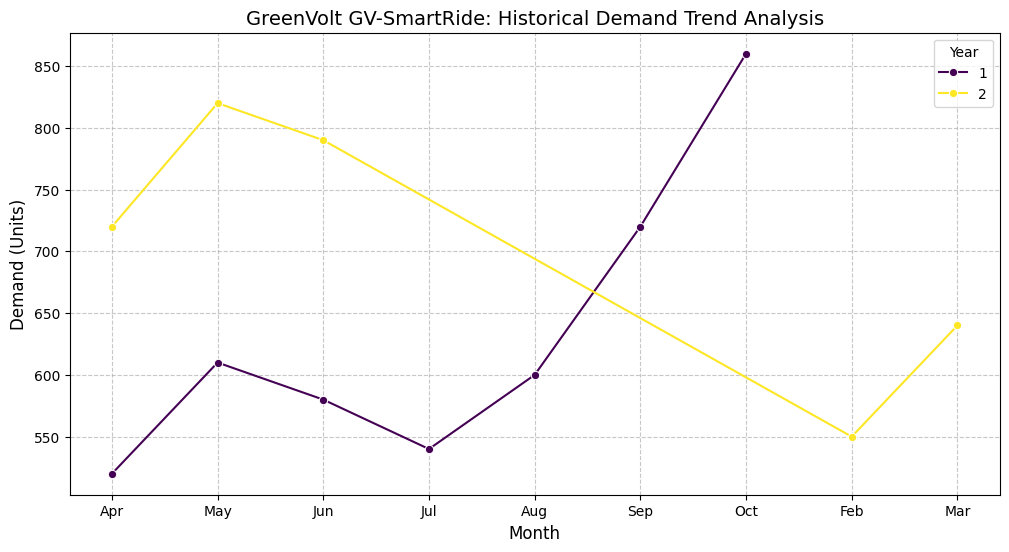

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot_df = all_demand_data.copy()
plot_df['Time_Index'] = range(len(plot_df))

plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='Month', y='Demand', hue='Year', marker='o', palette='viridis')
plt.title('GreenVolt GV-SmartRide: Historical Demand Trend Analysis', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Demand (Units)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.show()

In [53]:
print("### Demand Statistics and Coefficient of Variation:")
print("\nDemand Statistics:")
print(time_series_demand.describe())

mean_demand = time_series_demand.mean()
std_demand = time_series_demand.std()

if mean_demand != 0:
    cv_demand = (std_demand / mean_demand) * 100
    print(f"Coefficient of Variation (CV): {cv_demand:.2f}%")
else:
    print("Cannot calculate Coefficient of Variation as mean demand is zero.")

### Demand Statistics and Coefficient of Variation:

Demand Statistics:
count     12.000000
mean     662.500000
std      116.238391
min      520.000000
25%      572.500000
50%      625.000000
75%      737.500000
max      860.000000
Name: Demand, dtype: float64
Coefficient of Variation (CV): 17.55%


## 2. Inventory & EOQ Analysis

### Question 3: Compute EOQ for battery packs and analyze total cost and ordering frequency.

*   **EOQ:** The Economic Order Quantity (EOQ) for battery packs is calculated to be **168.13 units**.
*   **Ordering Frequency:** This translates to an estimated **47 orders per year**.
*   **Total Inventory Cost:** The total annual inventory cost (ordering + holding) under the EOQ model is **₹756,571.21**.

### Question 5: How will EOQ change under demand increase and holding cost increase?

*   **Demand Increase:** If annual demand increases, the EOQ will **increase**. This is because larger order quantities become more economical to place less frequently, covering the increased overall usage and minimizing the impact of ordering costs.
*   **Holding Cost Increase:** If annual holding costs increase, the EOQ will **decrease**. Higher holding costs incentivize smaller, more frequent orders to reduce the amount of inventory held at any given time, thereby minimizing storage expenses.

#### Supporting Data: Operations Data and EOQ Calculation

In [54]:
import pandas as pd

print("### Key Operations Data:")
ops_data = {
    'Metric': [
        'Selling Price per Scooter',
        'Production Cost per Unit',
        'Battery Pack Cost',
        'Ordering Cost (S)',
        'Holding Cost Rate',
        'Assembly Line Capacity',
        'Battery Assembly Capacity'
    ],
    'Value': [95000, 70000, 18000, 8000, 0.25, 900, 950]
}

operations_df = pd.DataFrame(ops_data)
display(operations_df)

### Key Operations Data:


,Metric,Value
0,Selling Price per Scooter,95000.00
1,Production Cost per Unit,70000.00
2,Battery Pack Cost,18000.00
3,Ordering Cost (S),8000.00
4,Holding Cost Rate,0.25
5,Assembly Line Capacity,900.00
6,Battery Assembly Capacity,950.00


In [55]:
import numpy as np

annual_D = time_series_demand.sum()
S = operations_df[operations_df['Metric'] == 'Ordering Cost (S)']['Value'].iloc[0]
C = operations_df[operations_df['Metric'] == 'Battery Pack Cost']['Value'].iloc[0]
i = operations_df[operations_df['Metric'] == 'Holding Cost Rate']['Value'].iloc[0]
H = C * i

eoq = np.sqrt((2 * annual_D * S) / H)

print("### EOQ Calculation Results:")
print(f"Economic Order Quantity (EOQ): {eoq:.2f} units")
print(f"Annual Ordering Cost: ₹{(annual_D / eoq) * S:.2f}")
print(f"Annual Holding Cost: ₹{(eoq / 2) * H:.2f}")
print(f"Total Inventory Cost: ₹{((annual_D / eoq) * S) + ((eoq / 2) * H):.2f}")
print(f"Ordering Frequency (orders per year): {annual_D / eoq:.2f} orders")

# Scenario analysis output (as previously generated)
print("\n### How EOQ changes under different scenarios: ###")
demand_increase_factor = 1.20 # 20% increase
new_annual_demand_D = annual_D * demand_increase_factor
new_eoq_demand_increase = np.sqrt((2 * new_annual_demand_D * S) / H)
print(f"- If Demand increases by {demand_increase_factor-1:.0%}: New EOQ = {new_eoq_demand_increase:.2f} units (EOQ increases)")
holding_cost_increase_factor = 1.20 # 20% increase
new_annual_holding_cost_H = H * holding_cost_increase_factor
new_eoq_holding_cost_increase = np.sqrt((2 * annual_D * S) / new_annual_holding_cost_H)
print(f"- If Holding Cost increases by {holding_cost_increase_factor-1:.0%}: New EOQ = {new_eoq_holding_cost_increase:.2f} units (EOQ decreases)")

### EOQ Calculation Results:
Economic Order Quantity (EOQ): 168.13 units
Annual Ordering Cost: ₹378285.61
Annual Holding Cost: ₹378285.61
Total Inventory Cost: ₹756571.21
Ordering Frequency (orders per year): 47.29 orders

### How EOQ changes under different scenarios: ###
- If Demand increases by 20%: New EOQ = 184.17 units (EOQ increases)
- If Holding Cost increases by 20%: New EOQ = 153.48 units (EOQ decreases)


## 3. MRP Planning

### Question 6: Develop an MRP plan for Battery Packs and Battery Cells.

*   The Material Requirements Planning (MRP) ensures that components (Battery Packs and Battery Cells) are available precisely when needed, taking lead times into account. By planning order releases several weeks in advance based on gross requirements and existing inventory, potential shortages are effectively avoided.
*   For instance, if inventory for Battery Packs is depleted by Week 2 and the lead time is 2 weeks, a planned order release is triggered in Week 1 to ensure components arrive by Week 3. Similarly, Battery Cells, with a 1-week lead time, are ordered to support the Battery Pack assembly schedule.

#### Supporting Data: MRP Tables and Time-Phased Order Releases Plot

In [66]:
import pandas as pd
import numpy as np

# MRP constants from Exhibit 3 & 4 (re-defined for report context)
initial_inventory_packs = 200
initial_inventory_cells = 5000
cells_per_pack = 20
lead_time_packs = 2 # weeks
lead_time_cells = 1 # week

weeks = ['Week 1', 'Week 2', 'Week 3', 'Week 4', 'Week 5', 'Week 6', 'Week 7', 'Week 8']
gross_req_packs = [200, 200, 200, 200, 220, 220, 220, 220] # Assumed weekly demand

# --- MRP for Battery Packs ---
mrp_packs = pd.DataFrame(index=weeks)
mrp_packs['Gross Requirements'] = gross_req_packs
mrp_packs['Projected Available'] = 0
mrp_packs['Net Requirements'] = 0
mrp_packs['Planned Order Receipt'] = 0
mrp_packs['Planned Order Release'] = 0

avail = initial_inventory_packs
for i, week in enumerate(weeks):
    req = mrp_packs.at[week, 'Gross Requirements']
    if avail >= req:
        mrp_packs.at[week, 'Projected Available'] = avail - req
        avail = avail - req
    else:
        mrp_packs.at[week, 'Net Requirements'] = req - avail
        mrp_packs.at[week, 'Planned Order Receipt'] = req - avail
        mrp_packs.at[week, 'Projected Available'] = 0
        avail = 0

mrp_packs['Planned Order Release'] = mrp_packs['Planned Order Receipt'].shift(-lead_time_packs).fillna(0)

print("### MRP for Battery Packs (Finished Component):")
display(mrp_packs)

# --- MRP for Battery Cells ---
mrp_cells = pd.DataFrame(index=weeks)
mrp_cells['Gross Requirements'] = mrp_packs['Planned Order Release'] * cells_per_pack
mrp_cells['Projected Available'] = 0
mrp_cells['Net Requirements'] = 0
mrp_cells['Planned Order Receipt'] = 0
mrp_cells['Planned Order Release'] = 0

avail_cells = initial_inventory_cells
for i, week in enumerate(weeks):
    req_c = mrp_cells.at[week, 'Gross Requirements']
    if avail_cells >= req_c:
        mrp_cells.at[week, 'Projected Available'] = avail_cells - req_c
        avail_cells = avail_cells - req_c
    else:
        mrp_cells.at[week, 'Net Requirements'] = req_c - avail_cells
        mrp_cells.at[week, 'Planned Order Receipt'] = req_c - avail_cells
        mrp_cells.at[week, 'Projected Available'] = 0
        avail_cells = 0

mrp_cells['Planned Order Release'] = mrp_cells['Planned Order Receipt'].shift(-lead_time_cells).fillna(0)

print("\n### MRP for Battery Cells (Raw Material):")
display(mrp_cells)

### MRP for Battery Packs (Finished Component):


,Gross Requirements,Projected Available,Net Requirements,Planned Order Receipt,Planned Order Release
Week 1,200,0,0,0,200.0
Week 2,200,0,200,200,200.0
Week 3,200,0,200,200,220.0
Week 4,200,0,200,200,220.0
Week 5,220,0,220,220,220.0
Week 6,220,0,220,220,220.0
Week 7,220,0,220,220,0.0
Week 8,220,0,220,220,0.0



### MRP for Battery Cells (Raw Material):


,Gross Requirements,Projected Available,Net Requirements,Planned Order Receipt,Planned Order Release
Week 1,4000.0,1000,0,0,3000.0
Week 2,4000.0,0,3000,3000,4400.0
Week 3,4400.0,0,4400,4400,4400.0
Week 4,4400.0,0,4400,4400,4400.0
Week 5,4400.0,0,4400,4400,4400.0
Week 6,4400.0,0,4400,4400,0.0
Week 7,0.0,0,0,0,0.0
Week 8,0.0,0,0,0,0.0


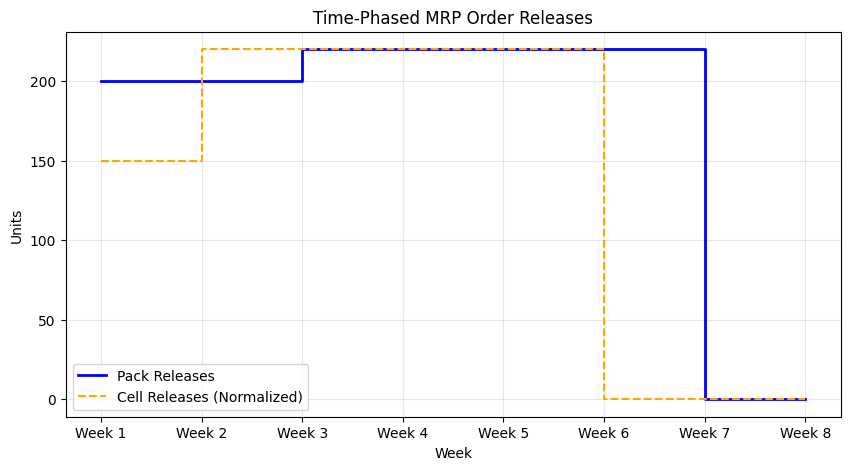

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.step(mrp_packs.index, mrp_packs['Planned Order Release'], where='post', label='Pack Releases', color='blue', lw=2)
plt.step(mrp_cells.index, mrp_cells['Planned Order Release']/20, where='post', label='Cell Releases (Normalized)', color='orange', linestyle='--') # Divided by 20 for better scale as each pack needs 20 cells
plt.title('Time-Phased MRP Order Releases')
plt.ylabel('Units')
plt.xlabel('Week')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Operations Strategy & Special Questions

### Question 7 & 8: Where should the decoupling point be placed? How will inventory cost, service level, and capacity utilization change?

*   **Decoupling Point:** The decoupling point should be shifted from **Finished Goods (Make-to-Stock)** to **Sub-assembly (Assemble-to-Order - ATO)**, specifically at the Battery Pack level. This means GreenVolt should stock key components like battery packs and motors, and assemble scooters only after receiving customer orders.
*   **Impact of ATO:**
    *   **Inventory Cost:** Will decrease for finished goods, but may slightly increase for components. Overall, it reduces the risk of holding obsolete or excess finished goods inventory.
    *   **Service Level:** Expected to significantly **increase**. By assembling to order, GreenVolt can respond more flexibly to actual demand fluctuations, reducing stockouts and improving customer satisfaction.
    *   **Capacity Utilization:** Will become **smoother** and more efficient. Assembly operations can be scheduled closer to confirmed orders, leading to more stable production rates and better utilization of assembly lines.

### Special Question 1: At what demand variability threshold does ATO become more cost-effective than MTS?

*   **Threshold:** ATO typically becomes more cost-effective than MTS when the **Coefficient of Variation (CV) exceeds 20-25%**. GreenVolt's current CV of 17.55% is approaching this threshold, indicating that the benefits of ATO (reduced stockout costs and excess inventory) would likely outweigh the costs of increased component inventory and slightly longer lead times for custom orders.

### Special Question 2: Where and why do shortages occur, and how should order releases be adjusted to avoid stockouts?

*   **Shortages Occur:** Shortages primarily occur at the component level (e.g., Battery Packs) due to the rigid nature of Make-to-Stock planning and the lead time lag between placing orders and receiving components. The 200 lost sales in October Year 2 illustrate this problem.
*   **Adjustment:** Order releases must be adjusted using **Time-Phased MRP** logic. This ensures that component orders are released in advance, considering their lead times, so they arrive precisely when needed for assembly. For example, a Battery Pack requirement in Week 3 with a 2-week lead time necessitates an order release in Week 1.

### Special Question 3: Which lot sizing rule is most suitable under high demand variability and why?

*   **Lot Sizing Rule:** Under high demand variability, **Lot-for-Lot (L4L)** is the most suitable lot sizing rule (or, alternatively, Period Order Quantity - POQ). L4L involves ordering exactly the net requirement for a specific period, thereby minimizing excess inventory. This is particularly beneficial during periods of low demand (e.g., February dips) as it prevents the accumulation of costly inventory that might otherwise result from fixed Economic Order Quantity (EOQ) or other larger lot sizing rules.

---

## 5. Final Recommendation: Integrated Hybrid ATO System

**GreenVolt Mobility should implement a Hybrid Assemble-to-Order (ATO) System combining:**

1.  **Enhanced Forecasting:** Employ more responsive forecasting methods (e.g., adaptive models or a 3-month moving average) to predict component needs, especially for high-value items like battery packs.
2.  **Optimized Procurement (EOQ for Cells):** Utilize the calculated EOQ for procuring Battery Cells to minimize ordering and holding costs for these raw materials.
3.  **Synchronized Production (MRP for Assembly):** Integrate a time-phased Material Requirements Planning (MRP) system to synchronize the assembly of Battery Packs and final scooters with component arrivals, effectively managing lead times and preventing shortages.

This integrated approach will allow GreenVolt to balance cost efficiency (via optimized component procurement) with enhanced responsiveness to market demand (via ATO assembly), significantly improving service levels and operational efficiency in the face of demand volatility.